# RNN for Text Classifications in NLP

# 1. Importing Required Libraries

We need to import necessary libraries such as TensorFlow for model building, NumPy for handling numerical operations and Matplotlib for visualizations.






In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

# 2. Loading the IMDB Dataset

The IMDB dataset contains movie reviews, labeled as positive or negative. We load the dataset and separate it into training and testing datasets. Batching the data into smaller chunks improves efficiency during training.

In [2]:
dataset = tfds.load('imdb_reviews', as_supervised=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

batch_size = 32
train_dataset = train_dataset.shuffle(10000)
train_dataset = train_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.QOEE6Q_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.QOEE6Q_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.QOEE6Q_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


# 3. Printing Sample Review and Label
We print a sample review and its corresponding label (0 for negative, 1 for positive) to understand the structure of the dataset.

In [3]:
example, label = next(iter(train_dataset))
print('Text:\n', example.numpy()[0])
print('\nLabel: ', label.numpy()[0])

Text:
 b'Since I first saw Anchors Aweigh in 1945, viewing it on videotape holds a lot of nostalgia for me. At age 15, it was easy for me to be drawn into the first of the great MGM Technicolor musicals. Now I am perhaps most interested in thinking about the future careers of the leading players. Though Sinatra had done a couple of negligible films soon after his emergence after his Dorsey days, as a solo singer, this was his first major film appearance. As another viewer noted, this seems almost to be a warm-up for On the Town. Sinatra may have had to work hard at it, but his dance with Kelly is credible, and he would do better in their next pairings. However, observing his physique, it\'s easy to see why he was caricatured as a string bean. Who would have imagined that within a decade he would win an academy award for acting, and go on to play many roles as a tough detective or leader in combat. Though Gene Kelly\'s personality and dancing dominated this film, his winsome performance

# 4. Text Vectorization
To convert the text into a numerical form, we use TensorFlow's text vectorization layer which tokenizes the text and converts each word into a sequence of integers. This prepares the text data for the neural network. We can also see in the example below how we can encode and decode the sample review into a vector of integers.

In [4]:
encoder = tf.keras.layers.TextVectorization(max_tokens=10000)
encoder.adapt(train_dataset.map(lambda text, _: text))

vocabulary = np.array(encoder.get_vocabulary())

original_text = example.numpy()[0]
encoded_text = encoder(original_text).numpy()
decoded_text = ' '.join(vocabulary[encoded_text])

print('original: ', original_text)
print('encoded: ', encoded_text)
print('decoded: ', decoded_text)

original:  b'Since I first saw Anchors Aweigh in 1945, viewing it on videotape holds a lot of nostalgia for me. At age 15, it was easy for me to be drawn into the first of the great MGM Technicolor musicals. Now I am perhaps most interested in thinking about the future careers of the leading players. Though Sinatra had done a couple of negligible films soon after his emergence after his Dorsey days, as a solo singer, this was his first major film appearance. As another viewer noted, this seems almost to be a warm-up for On the Town. Sinatra may have had to work hard at it, but his dance with Kelly is credible, and he would do better in their next pairings. However, observing his physique, it\'s easy to see why he was caricatured as a string bean. Who would have imagined that within a decade he would win an academy award for acting, and go on to play many roles as a tough detective or leader in combat. Though Gene Kelly\'s personality and dancing dominated this film, his winsome perform

# 5. Building the Model
We define the architecture of the RNN. This consists of the following layers:

TextVectorization Layer: Converts text into tokenized integers.
Embedding Layer: Converts tokens into dense vector representations.
Bidirectional LSTM Layers: Processes the sequence in both forward and backward directions.
Dense Layers: For final classification into positive or negative sentiment.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(1,), dtype=tf.string),
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 128)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,489 (2.87 MB)

 Trainable params: 751,489 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Compiling the Model
Now, we compile the model. The binary cross-entropy loss function is used since this is a binary classification task (positive or negative sentiment). We also specify the Adam optimizer and track accuracy as the evaluation metric.

In [6]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# 7. Training the Model
Next, we train the model using the training dataset for 5 epochs and validate it on the test dataset to evaluate its performance on unseen data.

In [7]:
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset,
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 1197s 2s/step - accuracy: 0.8045 - loss: 0.3985 - val_accuracy: 0.8678 - val_loss: 0.3113
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 1219s 2s/step - accuracy: 0.9075 - loss: 0.2238 - val_accuracy: 0.8773 - val_loss: 0.3051
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 1178s 1s/step - accuracy: 0.9021 - loss: 0.2283 - val_accuracy: 0.8488 - val_loss: 0.3477
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 1162s 1s/step - accuracy: 0.9480 - loss: 0.1335 - val_accuracy: 0.8415 - val_loss: 0.4321
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 1128s 1s/step - accuracy: 0.9710 - loss: 0.0814 - val_accuracy: 0.8586 - val_loss: 0.4622


# 8. Visualizing the Results
To visualize the performance of the model, we plot the training and validation accuracy and loss across epochs.

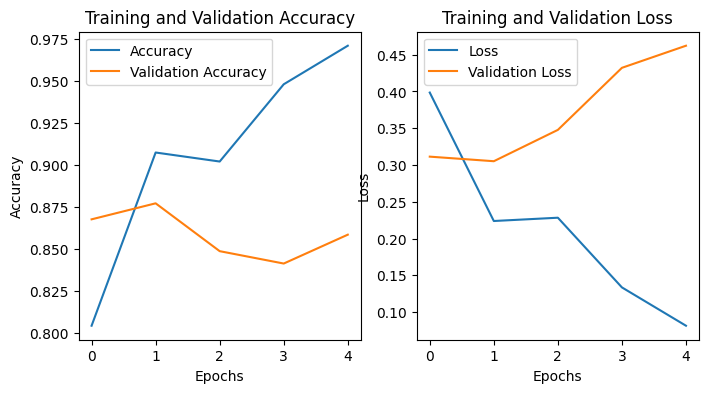

In [8]:
history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

loss = history_dict['loss']
val_loss = history_dict['val_loss']

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(acc)
plt.plot(val_acc)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Accuracy', 'Validation Accuracy'])

plt.subplot(1, 2, 2)
plt.plot(loss)
plt.plot(val_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss', 'Validation Loss'])

plt.show()

# 9. Testing the Trained Model
Finally, we test the trained model with a random movie review. The model predicts whether the review is positive or negative based on its learned patterns.

In [9]:
sample_text = (
    '''The movie by GeeksforGeeks was so good and the animation are so dope.
    I would recommend my friends to watch it.'''
)
sample_text_tensor = tf.constant([sample_text], dtype=tf.string)

predictions = model.predict(sample_text_tensor)

print("Prediction probability:", predictions[0])

if predictions[0] > 0.5:
    print('The review is positive')
else:
    print('The review is negative')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
Prediction probability: [2.3104568]
The review is positive


# **Advantages of RNNs for Text Classification**
Recurrent Neural Networks (RNNs) offer various advantages for text classification tasks in Natural Language Processing (NLP):

**Contextual Understanding:** RNNs capture the relationships between words, considering the order and context which is important for text classification tasks like sentiment analysis.

**Handling Sequential Data**: They are naturally suited for sequential data like text where the order of words matters.

**Variable-Length Sequences:** It can process text sequences of varying lengths, making them adaptable to different types of text.

# **Disadvantages of RNNs for Text Classification**
Despite being useful, RNNs have some limitations when used for text classification:

**Vanishing Gradient Problem**: It may struggle with long-term dependencies but this can be solved using LSTMs or GRUs.

**Limited Parallelization:** It process sequences one step at a time which can slow down training compared to other models.

**Sensitivity to Input Order** :They are sensitive to the input order which means small changes in word order can affect the output.